<a href="https://colab.research.google.com/github/konovalovae812-cmd/python_da_hw/blob/main/lisa_HW_11_2_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

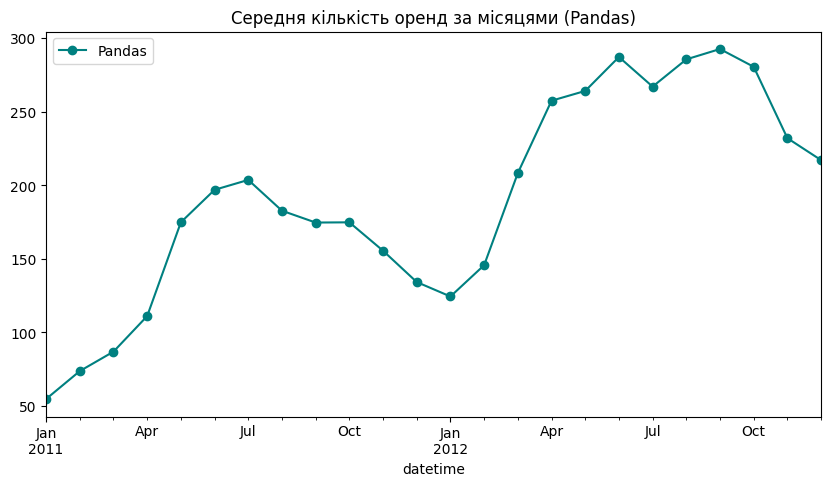

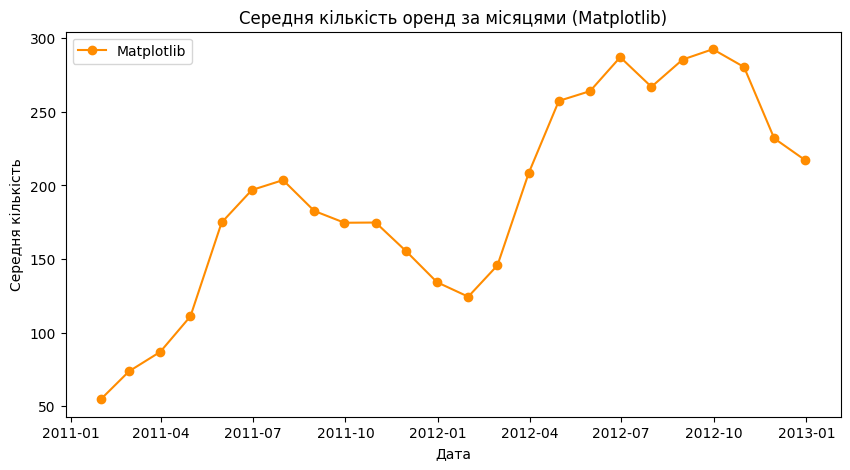

In [6]:
import matplotlib.pyplot as plt

monthly_avg = df['count'].resample('ME').mean()

#Спосіб 1: Pandas
monthly_avg.plot(kind='line', marker='o', color='teal', figsize=(10, 5), label='Pandas')
plt.title('Середня кількість оренд за місяцями (Pandas)')
plt.legend()
plt.show()

#Спосіб 2: Matplotlib безпосередньо
plt.figure(figsize=(10, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', color='darkorange', label='Matplotlib')
plt.title('Середня кількість оренд за місяцями (Matplotlib)')
plt.xlabel('Дата')
plt.ylabel('Середня кількість')
plt.legend()
plt.show()


## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [ ]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

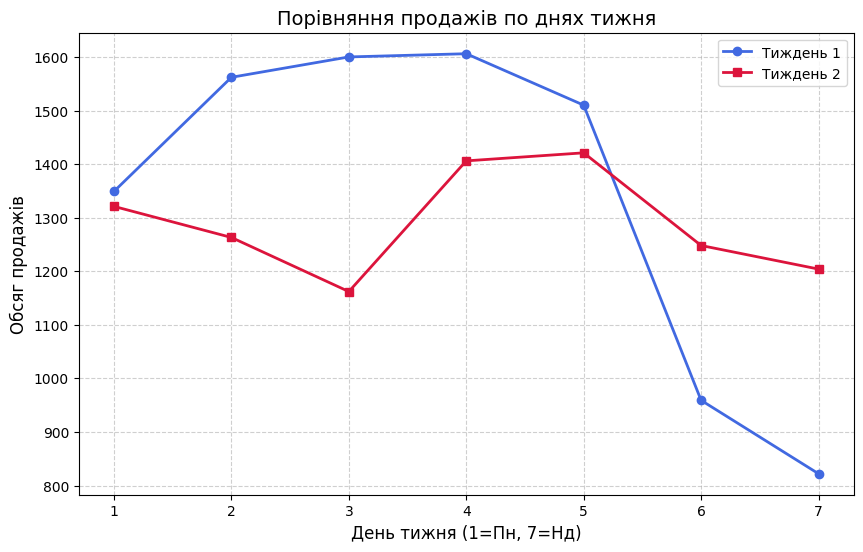

In [7]:
import matplotlib.pyplot as plt

# Дані
days = [1, 2, 3, 4, 5, 6, 7]
sales_week1 = [1349, 1562, 1600, 1606, 1510, 959, 822]
sales_week2 = [1321, 1263, 1162, 1406, 1421, 1248, 1204]

# Створення графіку
plt.figure(figsize=(10, 6))

# Побудова ліній для обох тижнів
plt.plot(days, sales_week1, marker='o', label='Тиждень 1', color='royalblue', linewidth=2)
plt.plot(days, sales_week2, marker='s', label='Тиждень 2', color='crimson', linewidth=2)

# Додавання назви та підписів осей
plt.title('Порівняння продажів по днях тижня', fontsize=14)
plt.xlabel('День тижня (1=Пн, 7=Нд)', fontsize=12)
plt.ylabel('Обсяг продажів', fontsize=12)

# Налаштування сітки та легенди
plt.xticks(days) # щоб на осі X були лише цілі числа днів
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Відображення
plt.show()


**Відповіді**
1. Другий тиждень був більш стабільним, ніж перший. На першому тижні був різкий спад на вихідних
2. Можна обчислити коефіцієнт варіації та розмах

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

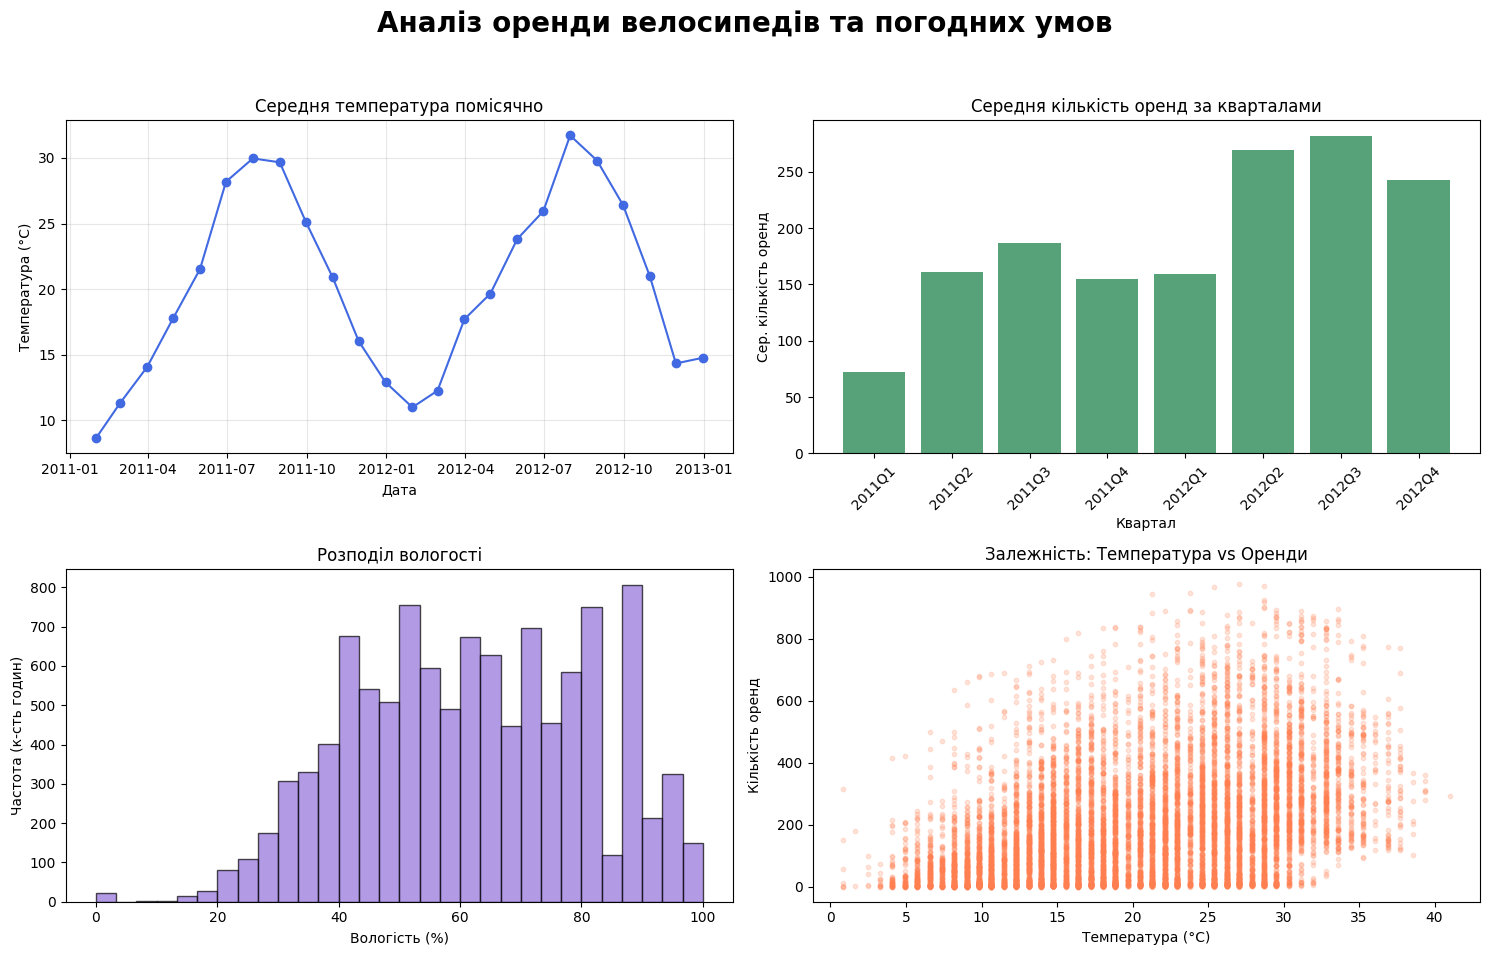

In [8]:
import matplotlib.pyplot as plt

# Налаштування загального розміру фігури
plt.figure(figsize=(15, 10))
plt.suptitle('Аналіз оренди велосипедів та погодних умов', fontsize=20, fontweight='bold')

# 1. Лінійний графік: Середня температура помісячно
plt.subplot(2, 2, 1)
temp_monthly = df['temp'].resample('ME').mean()
plt.plot(temp_monthly.index, temp_monthly.values, marker='o', color='royalblue')
plt.title('Середня температура помісячно')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.grid(True, alpha=0.3)

# 2. Стовпчикова діаграма: Середня кількість оренд за кварталами
plt.subplot(2, 2, 2)
rent_quarterly = df['count'].resample('QE').mean()
# Створимо зрозумілі підписи для кварталів (напр. 2011Q1)
quarter_labels = [f"{d.year}Q{(d.month-1)//3 + 1}" for d in rent_quarterly.index]
plt.bar(quarter_labels, rent_quarterly.values, color='seagreen', alpha=0.8)
plt.title('Середня кількість оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Сер. кількість оренд')
plt.xticks(rotation=45)

# 3. Гістограма вологості (humidity)
plt.subplot(2, 2, 3)
plt.hist(df['humidity'], bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
plt.title('Розподіл вологості')
plt.xlabel('Вологість (%)')
plt.ylabel('Частота (к-сть годин)')

# 4. Scatter plot: Температура vs Кількість оренд
plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['count'], alpha=0.2, color='coral', s=10)
plt.title('Залежність: Температура vs Оренди')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість оренд')

# Автоматичне вирівнювання підграфіків, щоб вони не накладалися
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

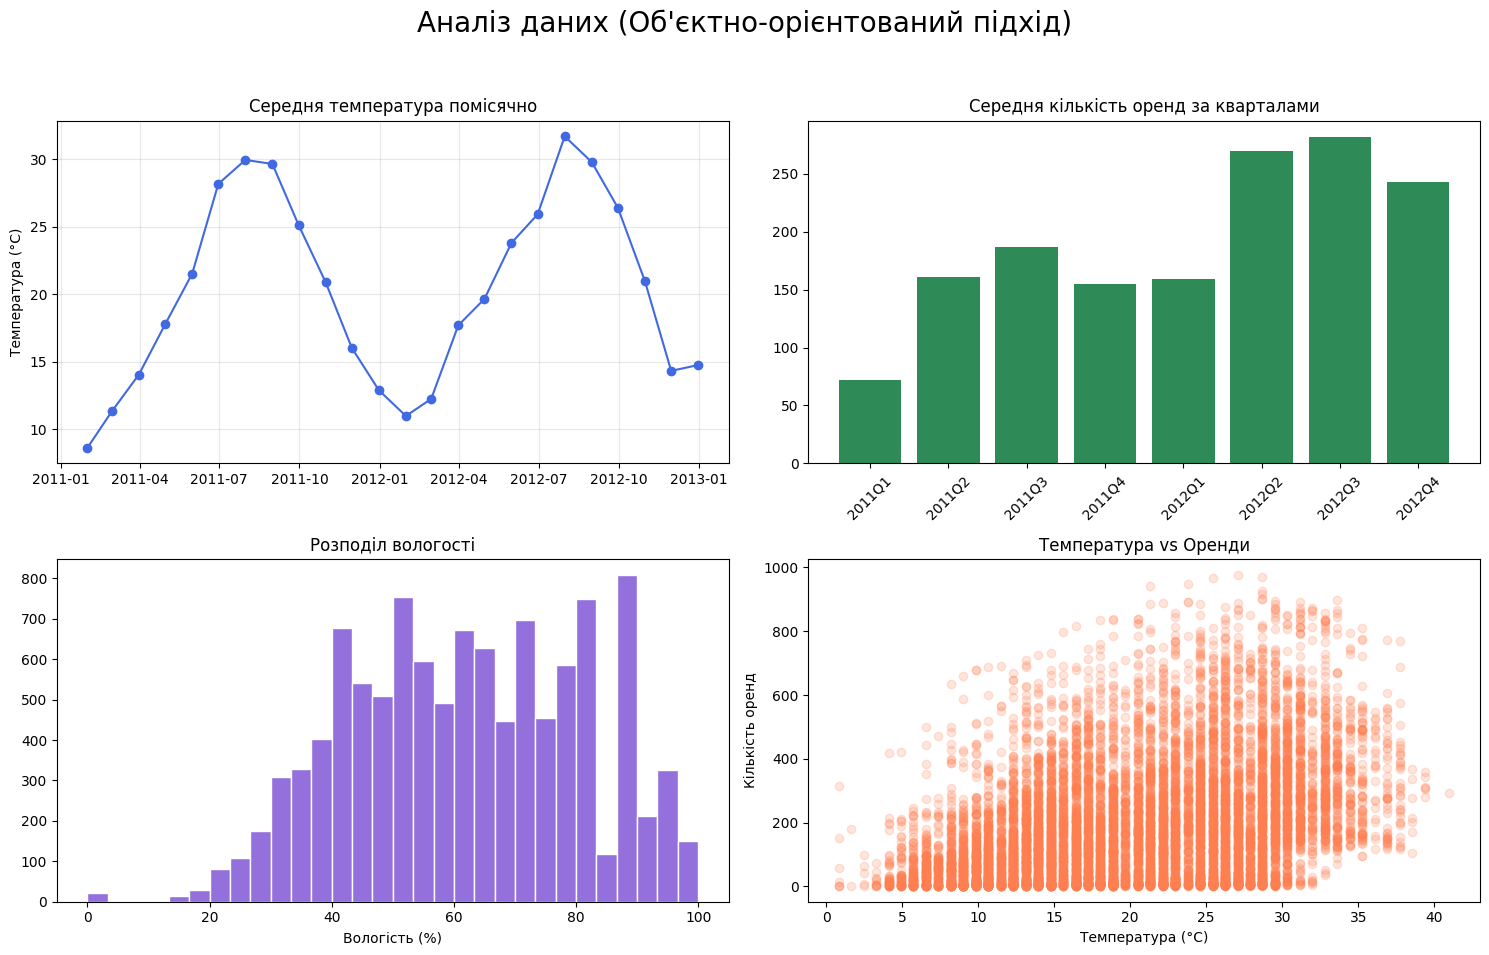

In [9]:
import matplotlib.pyplot as plt

# Створюємо фігуру та сітку осей (axes)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
fig.suptitle('Аналіз даних (Об\'єктно-орієнтований підхід)', fontsize=20)

# 1. Лінійний графік (доступ через індекси матриці [0, 0])
temp_monthly = df['temp'].resample('ME').mean()
axes[0, 0].plot(temp_monthly.index, temp_monthly.values, marker='o', color='royalblue')
axes[0, 0].set_title('Середня температура помісячно')
axes[0, 0].set_ylabel('Температура (°C)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Стовпчикова діаграма [0, 1]
rent_quarterly = df['count'].resample('QE').mean()
q_labels = [f"{d.year}Q{(d.month-1)//3 + 1}" for d in rent_quarterly.index]
axes[0, 1].bar(q_labels, rent_quarterly.values, color='seagreen')
axes[0, 1].set_title('Середня кількість оренд за кварталами')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Гістограма [1, 0]
axes[1, 0].hist(df['humidity'], bins=30, color='mediumpurple', edgecolor='white')
axes[1, 0].set_title('Розподіл вологості')
axes[1, 0].set_xlabel('Вологість (%)')

# 4. Scatter plot [1, 1]
axes[1, 1].scatter(df['temp'], df['count'], alpha=0.2, color='coral')
axes[1, 1].set_title('Температура vs Оренди')
axes[1, 1].set_xlabel('Температура (°C)')
axes[1, 1].set_ylabel('Кількість оренд')

# Налаштування відступів
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

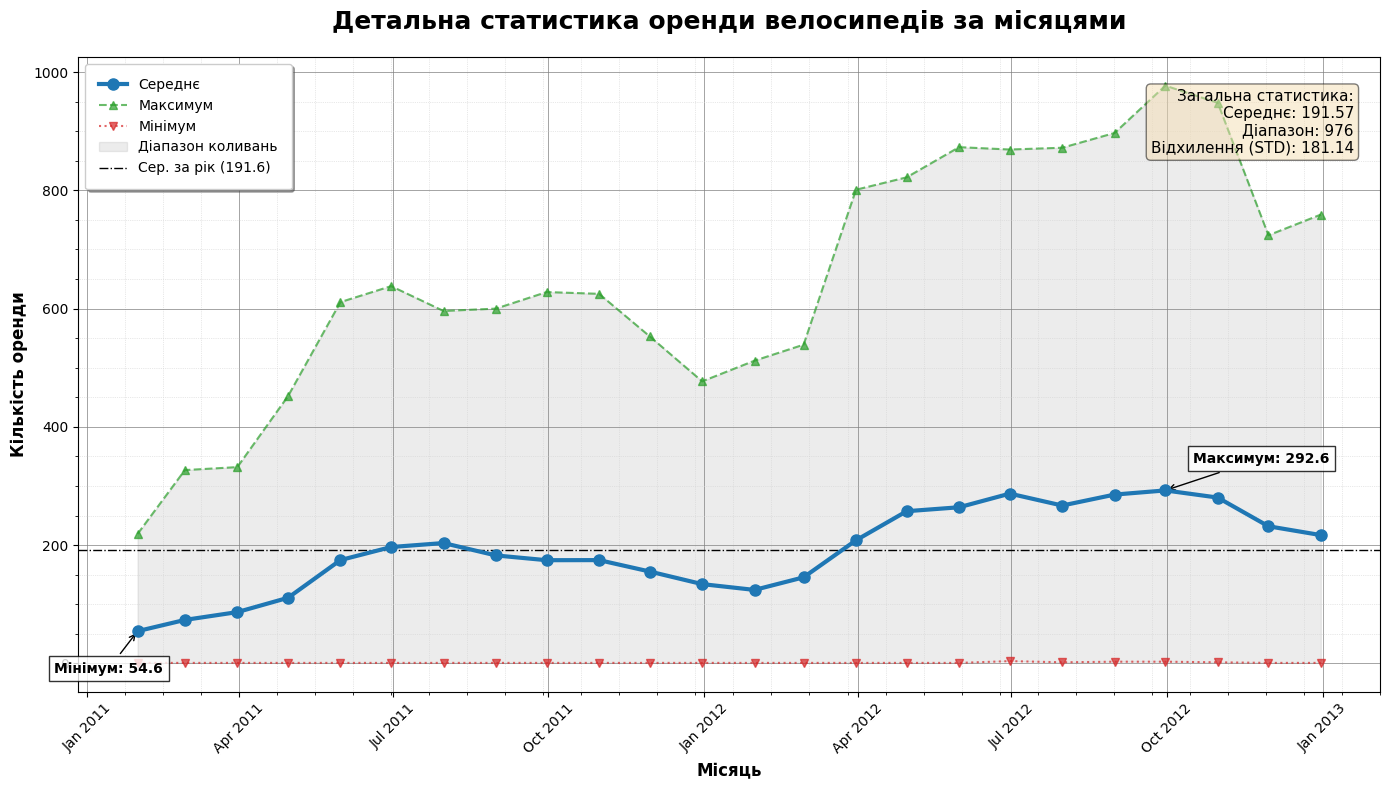

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Підготовка даних
monthly_data = df['count'].resample('ME').agg(['mean', 'max', 'min'])
overall_mean = df['count'].mean()
mean_val = df['count'].mean()
std_val = df['count'].std()
data_range = monthly_data['max'].max() - monthly_data['min'].min()

# Знаходження точок для анотацій
max_mean_val = monthly_data['mean'].max()
max_mean_date = monthly_data['mean'].idxmax()

min_mean_val = monthly_data['mean'].min()
min_mean_date = monthly_data['mean'].idxmin()

# 2. Створення графіку
fig, ax = plt.subplots(figsize=(14, 8), dpi=100)

# Побудова ліній
ax.plot(monthly_data.index, monthly_data['mean'], label='Середнє',
        color='#1f77b4', linewidth=3, marker='o', markersize=8, zorder=5)
ax.plot(monthly_data.index, monthly_data['max'], label='Максимум',
        color='#2ca02c', linestyle='--', marker='^', alpha=0.7)
ax.plot(monthly_data.index, monthly_data['min'], label='Мінімум',
        color='#d62728', linestyle=':', marker='v', alpha=0.7)

# Заливка області між Max та Min
ax.fill_between(monthly_data.index, monthly_data['min'], monthly_data['max'],
                color='gray', alpha=0.15, label='Діапазон коливань')

# Горизонтальна лінія середнього за рік
ax.axhline(overall_mean, color='black', linestyle='-.', linewidth=1,
           label=f'Сер. за рік ({overall_mean:.1f})')

# 3. Анотації
ax.annotate(f'Максимум: {max_mean_val:.1f}', xy=(max_mean_date, max_mean_val),
            xytext=(20, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

ax.annotate(f'Мінімум: {min_mean_val:.1f}', xy=(min_mean_date, min_mean_val),
            xytext=(-60, -30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

# 4. Статистика
stats_text = (f"Загальна статистика:\n"
              f"Середнє: {mean_val:.2f}\n"
              f"Діапазон: {data_range:.0f}\n"
              f"Відхилення (STD): {std_val:.2f}")

ax.text(0.98, 0.95, stats_text,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',      # Прив'язка до верхнього краю тексту
        horizontalalignment='right',   # Прив'язка до правого краю тексту
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 5. Налаштування сітки та осей
ax.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
ax.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray')
ax.minorticks_on()

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# 6. Заголовки та підписи
ax.set_title('Детальна статистика оренди велосипедів за місяцями',
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Місяць', fontsize=12, fontweight='bold')
ax.set_ylabel('Кількість оренди', fontsize=12, fontweight='bold')

# 7. Стилізована легенда
ax.legend(loc='upper left', shadow=True, fancybox=True, borderpad=1)

plt.tight_layout()
plt.show()

